<a href="https://colab.research.google.com/github/Chain361/vllm-concurrency-lab-101/blob/main/lab_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# vLLM vs HF Baseline - Concurrency Lab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nukaze/vllm-concurrency-lab-101/blob/main/lab.ipynb)

> **STEP 0 - ทำก่อนอื่นทั้งหมด:**
> 1. **File > Save a copy in Drive** - บันทึก notebook ลง Google Drive ของคุณก่อน ไม่งั้นถ้า runtime หลุดต้องเริ่มใหม่ทั้งหมด
> 2. **Runtime > Change runtime type > T4 GPU** - vLLM ต้องการ CUDA, CPU/TPU ใช้ไม่ได้

## What you will measure
| Exp | Metric | Method |
|-----|--------|--------|
| A | Single request latency | Send 1 request, measure time-to-completion |
| B | Concurrent throughput | Send N requests simultaneously, measure tokens/sec |
| C | Accuracy diff | Compare outputs from both engines on same prompt |

**Key question:** If the model weights are identical, why does choosing the serving engine
change whether your system handles 10 users or 200 users simultaneously?


In [13]:
import subprocess

# ตรวจสอบก่อนว่ามี NVIDIA GPU ไหม - vLLM ต้องการ CUDA เท่านั้น ถ้าไม่มีจะ error ทีหลังแบบงง
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError(
        'No GPU detected. Go to Runtime > Change runtime type > T4 GPU then reconnect.'
    )
print(result.stdout)

# แสดง CUDA toolkit version - ใช้ตรวจสอบว่า vllm wheel ที่ติดตั้งตรงกับ CUDA ไหม
nvcc = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
if nvcc.returncode == 0:
    print(nvcc.stdout)
else:
    print('nvcc not in PATH (nvidia-smi OK -- CUDA runtime available, toolkit PATH not set)')

Fri Jun 26 03:45:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |    3079MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q uv

# vllm 0.9+ requires CUDA 13 (libcudart.so.13) -- Colab T4 มี CUDA 12 เท่านั้น pin vllm<0.9
# transformers 5.0 ลบ all_special_tokens_extended ออก -- vllm 0.8.x ยังเรียก attribute นี้อยู่
# vllm 0.8.5 ต้องการ transformers>=4.51.1 ดังนั้น pin ให้ครอบทั้งสองด้าน
!uv pip install --system 'vllm<0.9' 'transformers>=4.51.1,<5.0' accelerate openai nest-asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 83.0 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 154 packages in 1.17s
Prepared 67 packages in 1m 33s
Uninstalled 32 packages in 1.71s
Installed 67 packages in 668ms
 + airportsdata==20260315
 + astor==0.8.1
 + blake3==1.0.9
 + compressed-tensors==0.9.3
 + deprecated==1.3.1
 + depyf==0.18.0
 + detect-installer==0.1.0
 + diskcache==5.6.3
 + dnspython==2.8.0
 + email-validator==2.3.0
 + fastapi-cli==0.0.27
 + fastapi-cloud-cli==0.21.0
 + fastar==0.11.0
 + gguf==0.19.0
 - huggingface-hub==1.19.0
 + huggingface-hub==0.36.2
 - importlib-metadata==8.7.1
 + importlib-metadata==8.0.0
 + interegular==0.3.3
 - lark==1.3.1
 + lark==1.2.2
 + llguidance==0.7.30
 - llvmlite==0.43.0
 + llvmlite==0.44.0
 + lm-format-enforcer==0.10.12
 + mistral-common==1.11.4
 + msgspec==0.21.1
 + ninja==1.13.0
 - numba==0.60.0
 + numba==0.61.2
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8

In [14]:
import os
# ป้องกัน transformers import tensorflow โดยอัตโนมัติ
# vllm ดาวน์เกรด protobuf เป็น version เก่าที่ TF ไม่รองรับ -- เราไม่ได้ใช้ TF เลย
os.environ['USE_TF'] = '0'

import torch
import time
import asyncio
import gc
import nest_asyncio
# Colab มี event loop รันอยู่แล้ว - nest_asyncio ทำให้เราซ้อน async loop ข้างในได้
# ถ้าไม่ apply จะได้ RuntimeError: This event loop is already running
nest_asyncio.apply()

MODEL_ID        = 'Qwen/Qwen2.5-1.5B-Instruct'
MAX_NEW_TOKENS  = 150
N_WARMUP        = 1
N_RUNS          = 5
CONCURRENCY_LEVELS = [1, 2, 4, 8, 16]

PROMPTS = [
    'Explain how a CPU works in simple terms.',
    'What is machine learning?',
    'Describe the water cycle.',
    'How does the internet work?',
    'What is photosynthesis?',
    'Explain gravity to a 10-year-old.',
    'What causes earthquakes?',
    'How do vaccines work?',
    'What is DNA?',
    'Explain supply and demand.',
    'How does a car engine work?',
    'What is blockchain?',
    'Describe the solar system.',
    'How do planes fly?',
    'What is climate change?',
    'Explain recursion in programming.',
    'Write simple banking mobile app for me',
    'Explain Quantum Theory for Sci-Math expert'
]
BENCHMARK_PROMPT = PROMPTS[0]

results = {'baseline': {}, 'vllm': {}}
print('Setup complete.')

Setup complete.


---
## Section 1 - HF Transformers Baseline
Naive serving: one request processed at a time, no batching optimization.
This is the pattern most tutorials use and what most people start with.


In [16]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f'Loading {MODEL_ID} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# float16 บังคับใช้เพราะ T4 (Turing architecture) ไม่รองรับ bfloat16
# device_map='auto' ให้ HF จัดการโหลด layer ลง GPU เองอัตโนมัติ
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map='auto'
)
model.eval()
print(f'Model loaded on: {next(model.parameters()).device}')
print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


Loading Qwen/Qwen2.5-1.5B-Instruct ...
Model loaded on: cuda:0
VRAM used: 3.10 GB


### Experiment HF A - Single Request Latency
วัดเวลาที่ HF Transformers ใช้ในการ complete 1 request ตั้งแต่ต้นจนจบ
นี่คือ baseline ที่ N=1 - ไม่มี queuing, ไม่มี concurrency pressure ใช้เป็น reference ก่อนจะ scale ขึ้นใน Exp B

In [17]:
def baseline_generate(prompt):
    # ต้องใช้ chat template เพื่อให้ baseline และ vLLM ได้รับ prompt format เดียวกัน
    # ถ้าไม่ทำ Exp C จะเทียบผลไม่ได้ เพราะ input จริงๆ ต่างกัน
    messages = [{'role': 'user', 'content': prompt}]
    text_input = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text_input, return_tensors='pt').to(model.device)
    with torch.no_grad():
        t0 = time.perf_counter()  # จับเวลาเริ่มต้น ก่อนที่ GPU จะเริ่มคำนวณ

        output = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)  # รัน autoregressive decoding บน GPU, do_sample=False = greedy (ไม่สุ่ม)

        t1 = time.perf_counter()  # จับเวลาสิ้นสุด หลัง GPU generate ครบทุก token แล้ว

    generated_ids = output[0][inputs['input_ids'].shape[1]:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    latency = t1 - t0
    n_tokens = len(generated_ids)
    return text, latency, n_tokens

# warmup 1 ครั้งก่อนวัดจริง - run แรก GPU ยัง cold อยู่ CUDA kernel ยังไม่ compile
# ถ้าไม่ warmup latency run แรกจะสูงผิดปกติทำให้ค่าเฉลี่ยเบี้ยว
baseline_generate(BENCHMARK_PROMPT)

_log = open('HF-A.log', 'w')
latencies = []
for i in range(N_RUNS):
    text, latency, n_tokens = baseline_generate(BENCHMARK_PROMPT)
    latencies.append(latency)
    tok_s = n_tokens / latency
    print(f'Run {i+1}: {latency:.2f}s | {tok_s:.1f} tok/s')
    _log.write(f'ask#{i+1}: {BENCHMARK_PROMPT}\n')
    _log.write(f'answer#{i+1}: {text}\n')
    _log.write(f'time: {latency:.2f}s | {tok_s:.1f} tok/s\n\n')

results['baseline']['exp_a'] = {
    'latencies': latencies,
    'mean': sum(latencies) / len(latencies),
    'output_sample': text,
}
mean = results['baseline']['exp_a']['mean']
print(f'\nMean latency: {mean:.2f}s')
_log.write(f'--- Summary ---\nMean latency: {mean:.2f}s\n')
_log.close()
print('Saved: HF-A.log')

Run 1: 7.11s | 21.1 tok/s
Run 2: 6.30s | 23.8 tok/s
Run 3: 6.70s | 22.4 tok/s
Run 4: 6.41s | 23.4 tok/s
Run 5: 6.53s | 23.0 tok/s

Mean latency: 6.61s
Saved: HF-A.log


### Experiment HF B - Concurrent Throughput
Baseline processes requests **sequentially** - this simulates a naive server
with no concurrency support. Watch throughput flatten as N increases.

In [18]:
baseline_exp_b = {}
_log = open('HF-B.log', 'w')

for n in CONCURRENCY_LEVELS:
    batch = [PROMPTS[i % len(PROMPTS)] for i in range(n)]
    t0 = time.perf_counter()
    total_tokens = 0
    _log.write(f'=== Concurrency {n} ===\n')
    for j, prompt in enumerate(batch):
        _log.write(f'ask#{j+1}: {prompt}\n')
    # loop นี้คือ naive serving - ประมวลผลทีละ request ไม่มี batching
    # จำลองว่า server ธรรมดารับ user 1 คนต่อครั้ง user ที่เหลือรอคิว
    cum = 0.0
    for j, prompt in enumerate(batch):
        text, latency, n_tok = baseline_generate(prompt)
        total_tokens += n_tok
        cum += latency
        _log.write(f'answer#{j+1}: {text}\n')
        _log.write(f'time: {latency:.2f}s | cumulative: {cum:.2f}s\n')
        print(f'  req {j+1}/{n}: {n_tok} tok | {latency:.2f}s | cum {cum:.2f}s')
    elapsed = time.perf_counter() - t0
    throughput = total_tokens / elapsed
    baseline_exp_b[n] = throughput
    print(f'Concurrency {n:2d} | {throughput:6.1f} tok/s | {elapsed:.1f}s total')
    _log.write(f'throughput: {throughput:.1f} tok/s | elapsed: {elapsed:.1f}s\n\n')

results['baseline']['exp_b'] = baseline_exp_b
_log.write('--- Summary ---\n')
for n, tps in baseline_exp_b.items():
    _log.write(f'Concurrency {n:2d}: {tps:.1f} tok/s\n')
_log.close()
print('\nBaseline Exp B done.')
print('Saved: HF-B.log')

  req 1/1: 150 tok | 6.52s | cum 6.52s
Concurrency  1 |   23.0 tok/s | 6.5s total
  req 1/2: 150 tok | 6.85s | cum 6.85s
  req 2/2: 150 tok | 7.75s | cum 14.60s
Concurrency  2 |   20.5 tok/s | 14.6s total
  req 1/4: 150 tok | 14.14s | cum 14.14s
  req 2/4: 150 tok | 6.26s | cum 20.40s
  req 3/4: 150 tok | 6.83s | cum 27.23s
  req 4/4: 150 tok | 6.20s | cum 33.43s
Concurrency  4 |   17.9 tok/s | 33.5s total
  req 1/8: 150 tok | 6.72s | cum 6.72s
  req 2/8: 150 tok | 6.15s | cum 12.87s
  req 3/8: 150 tok | 6.82s | cum 19.69s
  req 4/8: 150 tok | 6.24s | cum 25.93s
  req 5/8: 150 tok | 6.86s | cum 32.79s
  req 6/8: 132 tok | 5.48s | cum 38.27s
  req 7/8: 150 tok | 6.92s | cum 45.20s
  req 8/8: 150 tok | 6.42s | cum 51.62s
Concurrency  8 |   22.9 tok/s | 51.7s total
  req 1/16: 150 tok | 6.81s | cum 6.81s
  req 2/16: 150 tok | 6.65s | cum 13.46s
  req 3/16: 150 tok | 6.42s | cum 19.88s
  req 4/16: 150 tok | 6.98s | cum 26.86s
  req 5/16: 150 tok | 6.34s | cum 33.20s
  req 6/16: 132 tok | 6

### Free VRAM before starting vLLM
vLLM loads its own copy of the model. We unload the HF model first
to avoid running out of VRAM on T4.


In [19]:
# ต้อง unload HF model ออกก่อน ไม่งั้น vLLM จะโหลด model ซ้ำแล้ว VRAM เต็ม (OOM)
del model
gc.collect()            # Python garbage collector คืน memory
torch.cuda.empty_cache()  # คืน CUDA caching pool กลับให้ OS

# memory_reserved รวม caching pool ด้วย แม่นกว่า memory_allocated
# ถ้า reserved ยังสูงอยู่ vLLM อาจ OOM ตอน startup
print(f'VRAM reserved after unload: {torch.cuda.memory_reserved()/1e9:.2f} GB')
print(f'VRAM allocated after unload: {torch.cuda.memory_allocated()/1e9:.2f} GB')


VRAM reserved after unload: 3.09 GB
VRAM allocated after unload: 0.01 GB


---
## Section 2 - vLLM
vLLM uses **PagedAttention** + **continuous batching**:
- KV cache is managed as non-contiguous blocks (no fragmentation)
- New requests join an in-progress batch immediately (no waiting for a batch to finish)

The client code uses the same OpenAI-compatible API - no client changes needed.


In [20]:
import requests as req

# เก็บ log ไว้ใน file แทน DEVNULL เพื่อ debug ได้ถ้า server crash
log_file = open('vllm_server.log', 'w')
vllm_proc = subprocess.Popen(
    [
        'vllm', 'serve', MODEL_ID,
        '--port', '8000',
        '--dtype', 'float16',       # T4 ต้องใช้ float16
        '--max-model-len', '2048',  # จำกัด context length ประหยัด KV cache VRAM
        '--gpu-memory-utilization', '0.80',  # จอง VRAM 80% ให้ KV cache เหลือ headroom
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,  # รวม stderr เข้า log file เดียวกัน
)

print('Starting vLLM server', end='', flush=True)
for _ in range(90):
    # poll() คืน None ถ้า process ยังรันอยู่ ถ้าได้ exit code แปลว่า crash แล้ว
    if vllm_proc.poll() is not None:
        log_file.flush()
        raise RuntimeError(
            f'vLLM exited early (code {vllm_proc.returncode}). '
            'Open vllm_server.log in the file browser for details.'
        )
    try:
        if req.get('http://localhost:8000/v1/models', timeout=2).status_code == 200:
            print(' ready!')
            break
    except Exception:
        pass
    print('.', end='', flush=True)
    time.sleep(3)
else:
    log_file.flush()
    last_log = open('vllm_server.log').read()[-2000:]
    raise RuntimeError(f'vLLM did not start in time. Last log:\n{last_log}')


Starting vLLM server.................................. ready!


### Experiment vLLM A - Single Request Latency
วัดเหมือน HF-A แต่ส่ง request ผ่าน vLLM HTTP server แทน
ที่ N=1 จะเห็น overhead ของ HTTP layer เทียบกับ HF-A เพื่อดู cost ของ single request ก่อนที่ concurrency จะเปลี่ยนภาพใน Exp B

In [22]:
from openai import OpenAI

client = OpenAI(base_url='http://localhost:8000/v1', api_key='dummy')

def vllm_generate(prompt):
    t0 = time.perf_counter()
    # TODO: เรียก client.chat.completions.create() ด้วย
    #   model=MODEL_ID, messages=[{'role':'user','content':prompt}]
    #   max_tokens=MAX_NEW_TOKENS, temperature=0
    resp = client.chat.completions.create(  # ส่ง HTTP POST ไปยัง vLLM server ที่ localhost:8000 (OpenAI-compatible API)
        model=MODEL_ID,  # ชื่อ model ที่ serve อยู่บน server ต้องตรงกับที่ vLLM โหลดไว้
        messages=[{'role': 'user', 'content': prompt}],  # prompt ในรูปแบบ chat message เหมือน ChatGPT API
        max_tokens=MAX_NEW_TOKENS,  # จำกัด output tokens ให้เท่ากับ baseline เพื่อเทียบกันได้
        temperature=0,  # greedy decoding ไม่สุ่ม ผลลัพธ์ deterministic เหมือน do_sample=False
    )

    latency = time.perf_counter() - t0
    text = resp.choices[0].message.content
    n_tokens = resp.usage.completion_tokens
    return text, latency, n_tokens

# warmup
vllm_generate(BENCHMARK_PROMPT)

_log = open('vLLM-A.log', 'w')
latencies = []
for i in range(N_RUNS):
    text, latency, n_tokens = vllm_generate(BENCHMARK_PROMPT)
    latencies.append(latency)
    tok_s = n_tokens / latency
    print(f'Run {i+1}: {latency:.2f}s | {tok_s:.1f} tok/s')
    _log.write(f'ask#{i+1}: {BENCHMARK_PROMPT}\n')
    _log.write(f'answer#{i+1}: {text}\n')
    _log.write(f'time: {latency:.2f}s | {tok_s:.1f} tok/s\n\n')

results['vllm']['exp_a'] = {
    'latencies': latencies,
    'mean': sum(latencies) / len(latencies),
    'output_sample': text,
}
mean = results['vllm']['exp_a']['mean']
print(f'\nMean latency: {mean:.2f}s')
_log.write(f'--- Summary ---\nMean latency: {mean:.2f}s\n')
_log.close()
print('Saved: vLLM-A.log')

Run 1: 2.55s | 58.8 tok/s
Run 2: 2.58s | 58.1 tok/s
Run 3: 2.59s | 57.9 tok/s
Run 4: 2.64s | 56.8 tok/s
Run 5: 2.69s | 55.8 tok/s

Mean latency: 2.61s
Saved: vLLM-A.log


### Experiment vLLM B - Concurrent Throughput
vLLM receives all N requests simultaneously and handles them with continuous batching.
Compare the throughput curve against the baseline.

In [24]:
from openai import AsyncOpenAI

async_client = AsyncOpenAI(base_url='http://localhost:8000/v1', api_key='dummy')

# AsyncOpenAI ส่ง HTTP request แบบ non-blocking ทำให้ await ได้โดยไม่ block thread
async def vllm_generate_async(prompt):
    t0 = time.perf_counter()
    resp = await async_client.chat.completions.create(
        model=MODEL_ID,
        messages=[{'role': 'user', 'content': prompt}],
        max_tokens=MAX_NEW_TOKENS,
        temperature=0,
    )
    return resp.usage.completion_tokens, resp.choices[0].message.content, time.perf_counter() - t0

async def run_concurrent(n):
    batch = [PROMPTS[i % len(PROMPTS)] for i in range(n)]
    t0 = time.perf_counter()
    # asyncio.gather ส่ง request ทุกตัวพร้อมกันในทีเดียว
    # vLLM ฝั่ง server รับทุก request แล้วจัดการผ่าน continuous batching อัตโนมัติ
    # TODO: ใช้ asyncio.gather() เพื่อส่ง vllm_generate_async(p) พร้อมกันทุก prompt ใน batch
    # แต่ละ result คือ (n_tokens, text) -- unpack เป็น token_counts และ texts
    pairs = await asyncio.gather(*[vllm_generate_async(p) for p in batch])
    token_counts = [p[0] for p in pairs]
    texts = [p[1] for p in pairs]
    latencies = [p[2] for p in pairs]
    elapsed = time.perf_counter() - t0
    return sum(token_counts) / elapsed, elapsed, batch, texts, latencies

async def run_all_concurrent():
    out = {}
    _log = open('vLLM-B.log', 'w')
    for n in CONCURRENCY_LEVELS:
        throughput, elapsed, batch, texts, latencies = await run_concurrent(n)
        out[n] = throughput
        print(f'Concurrency {n:2d} | {throughput:6.1f} tok/s | {elapsed:.1f}s total')
        _log.write(f'=== Concurrency {n} ===\n')
        for j, (prompt, text, lat) in enumerate(zip(batch, texts, latencies)):
            _log.write(f'ask#{j+1}: {prompt}\n')
            _log.write(f'answer#{j+1}: {text}\n')
            _log.write(f'time: {lat:.2f}s\n')
            print(f'  req {j+1}/{n}: {len(text)} chars | {lat:.2f}s')
        _log.write(f'throughput: {throughput:.1f} tok/s | elapsed: {elapsed:.1f}s\n\n')
    _log.write('--- Summary ---\n')
    for n, tps in out.items():
        _log.write(f'Concurrency {n:2d}: {tps:.1f} tok/s\n')
    _log.close()
    print('Saved: vLLM-B.log')
    return out

# ใช้ get_event_loop().run_until_complete() แทน asyncio.run()
# เพราะ asyncio.run() จะ close loop หลังจบ ทำให้ AsyncOpenAI client error ใน iteration ถัดไป
vllm_exp_b = asyncio.get_event_loop().run_until_complete(run_all_concurrent())
results['vllm']['exp_b'] = vllm_exp_b
print('\nvLLM Exp B done.')

Concurrency  1 |   59.3 tok/s | 2.5s total
  req 1/1: 777 chars | 2.53s
Concurrency  2 |  114.4 tok/s | 2.6s total
  req 1/2: 784 chars | 2.62s
  req 2/2: 853 chars | 2.62s
Concurrency  4 |  227.7 tok/s | 2.6s total
  req 1/4: 784 chars | 2.63s
  req 2/4: 833 chars | 2.63s
  req 3/4: 697 chars | 2.63s
  req 4/4: 819 chars | 2.63s
Concurrency  8 |  425.0 tok/s | 2.8s total
  req 1/8: 784 chars | 2.82s
  req 2/8: 853 chars | 2.82s
  req 3/8: 697 chars | 2.82s
  req 4/8: 819 chars | 2.81s
  req 5/8: 746 chars | 2.82s
  req 6/8: 769 chars | 2.81s
  req 7/8: 746 chars | 2.81s
  req 8/8: 804 chars | 2.81s
Concurrency 16 |  733.4 tok/s | 3.3s total
  req 1/16: 784 chars | 3.27s
  req 2/16: 853 chars | 3.27s
  req 3/16: 697 chars | 3.26s
  req 4/16: 819 chars | 3.26s
  req 5/16: 746 chars | 3.26s
  req 6/16: 769 chars | 3.26s
  req 7/16: 746 chars | 3.26s
  req 8/16: 804 chars | 3.26s
  req 9/16: 698 chars | 3.26s
  req 10/16: 796 chars | 3.26s
  req 11/16: 740 chars | 3.26s
  req 12/16: 833 c

### Experiment C - Output Accuracy Diff
Same weights, same prompt. Are the outputs identical?
Minor floating-point differences are expected but meaning should be the same.


In [25]:
from difflib import SequenceMatcher
from datetime import datetime

baseline_out = results['baseline']['exp_a']['output_sample']
vllm_out     = results['vllm']['exp_a']['output_sample']
similarity   = SequenceMatcher(None, baseline_out, vllm_out).ratio()

print(f'Prompt: {BENCHMARK_PROMPT}\n')
print(f'--- Baseline output ---\n{baseline_out}\n')
print(f'--- vLLM output ---\n{vllm_out}\n')
print(f'Similarity score: {similarity:.4f}  (1.0 = identical)')

results['baseline']['exp_c'] = baseline_out
results['vllm']['exp_c']     = vllm_out
results['similarity']        = similarity

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
log_name = f'ExpC_{ts}.log'
with open(log_name, 'w') as f:
    f.write(f'Prompt: {BENCHMARK_PROMPT}\n\n')
    f.write(f'--- Baseline output ---\n{baseline_out}\n\n')
    f.write(f'--- vLLM output ---\n{vllm_out}\n\n')
    f.write(f'Similarity score: {similarity:.4f}\n')
print(f'Saved: {log_name}')

Prompt: Explain how a CPU works in simple terms.

--- Baseline output ---
A CPU (Central Processing Unit) is the brain of a computer and it's responsible for executing instructions that make up software programs. It does this by taking input from memory or other parts of the computer system, performing calculations on that data, and then outputting results back to memory or another part of the system.

The CPU contains several components including:

1. Arithmetic Logic Unit (ALU): This performs arithmetic operations like addition, subtraction, multiplication, division, etc.
2. Control Unit: This controls the flow of information between different parts of the CPU and the rest of the computer system.
3. Registers: These temporary storage locations where data can be quickly accessed and manipulated by the ALU.
4. Cache Memory: A small amount of fast

--- vLLM output ---
A CPU (Central Processing Unit) is the brain of a computer and it's responsible for executing instructions that make up 

---
## Section 3 - Results


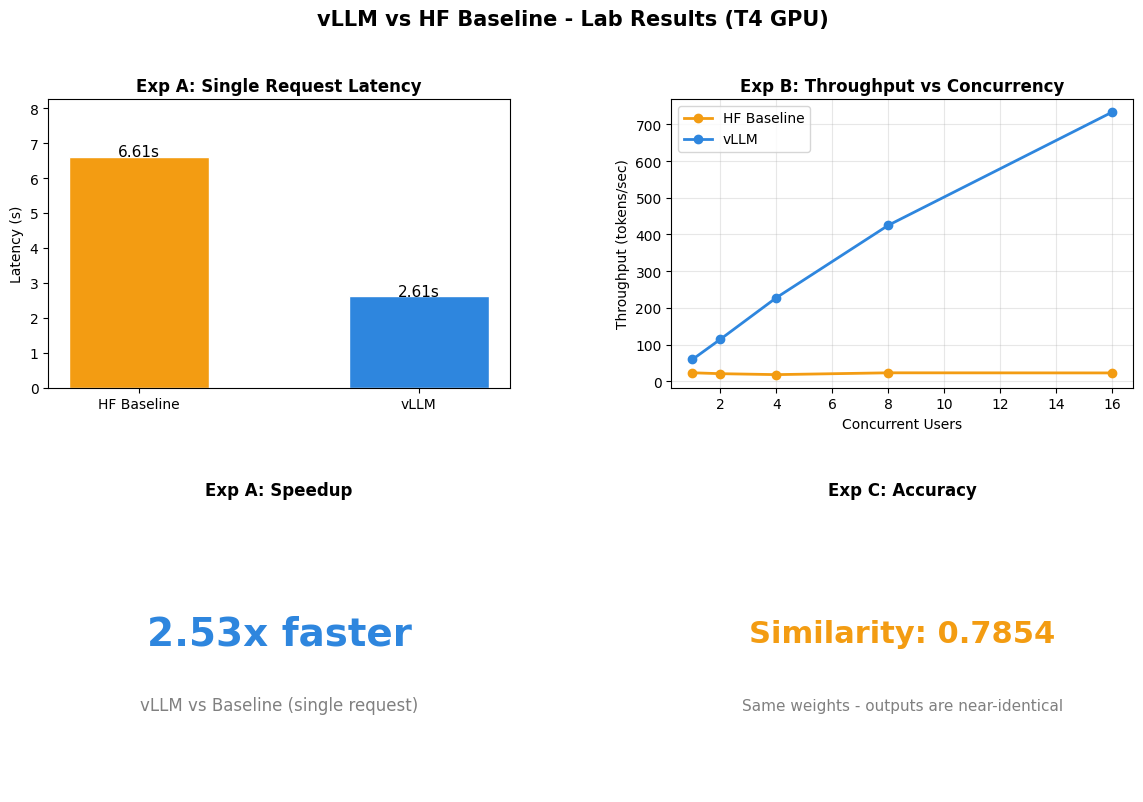

Saved: results_comparison.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ORANGE, AZURE = '#f39c12', '#2e86de'

# Exp A - latency bar
ax1 = fig.add_subplot(gs[0, 0])
labels = ['HF Baseline', 'vLLM']
means  = [results['baseline']['exp_a']['mean'], results['vllm']['exp_a']['mean']]
bars   = ax1.bar(labels, means, color=[ORANGE, AZURE], width=0.5, edgecolor='white')
ax1.set_title('Exp A: Single Request Latency', fontweight='bold')
ax1.set_ylabel('Latency (s)')
for b, v in zip(bars, means):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}s', ha='center', fontsize=11)
ax1.set_ylim(0, max(means) * 1.25)

# Exp B - throughput line
ax2 = fig.add_subplot(gs[0, 1])
x   = list(results['baseline']['exp_b'].keys())
ax2.plot(x, list(results['baseline']['exp_b'].values()), 'o-', color=ORANGE, label='HF Baseline', lw=2)
ax2.plot(x, list(results['vllm']['exp_b'].values()),     'o-', color=AZURE,  label='vLLM', lw=2)
ax2.set_title('Exp B: Throughput vs Concurrency', fontweight='bold')
ax2.set_xlabel('Concurrent Users')
ax2.set_ylabel('Throughput (tokens/sec)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Exp A speedup annotation
ax3 = fig.add_subplot(gs[1, 0])
speedup = means[0] / means[1] if means[1] > 0 else 0
ax3.text(0.5, 0.55, f'{speedup:.2f}x faster', ha='center', va='center',
         fontsize=28, fontweight='bold', color=AZURE, transform=ax3.transAxes)
ax3.text(0.5, 0.3, 'vLLM vs Baseline (single request)', ha='center', va='center',
         fontsize=12, color='gray', transform=ax3.transAxes)
ax3.set_title('Exp A: Speedup', fontweight='bold')
ax3.axis('off')

# Exp C similarity (optional -- only if Exp C was run)
ax4 = fig.add_subplot(gs[1, 1])
sim = results.get('similarity')
if sim is not None:
    color = AZURE if sim > 0.95 else ORANGE
    ax4.text(0.5, 0.55, f'Similarity: {sim:.4f}', ha='center', va='center',
             fontsize=22, fontweight='bold', color=color, transform=ax4.transAxes)
    ax4.text(0.5, 0.3, 'Same weights - outputs are near-identical', ha='center', va='center',
             fontsize=11, color='gray', transform=ax4.transAxes)
else:
    ax4.text(0.5, 0.5, 'Exp C not run yet', ha='center', va='center',
             fontsize=16, color='gray', transform=ax4.transAxes)
ax4.set_title('Exp C: Accuracy', fontweight='bold')
ax4.axis('off')

plt.suptitle('vLLM vs HF Baseline - Lab Results (T4 GPU)', fontsize=15, fontweight='bold')
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results_comparison.png')

---
## Cleanup
Stop the vLLM server process when done.


In [27]:
vllm_proc.terminate()
vllm_proc.wait()
log_file.close()
print('vLLM server stopped.')


vLLM server stopped.


---
## Conclusion - What You Actually Learned

### Exp A - Single Request Latency
HF Transformers โหลด model ไว้ใน process เดียวกัน เรียกได้เลย
vLLM ใช้ optimized CUDA kernels ทำให้เร็วกว่า HF แม้ที่ N=1 - HTTP overhead มีจริงแต่เล็กน้อยมากเมื่อเทียบกับ kernel speedup
**Takeaway:** ความได้เปรียบของ vLLM เริ่มตั้งแต่ request แรก แต่จะเห็นชัดขึ้นมากเมื่อ N เพิ่มขึ้น

### Exp B - Concurrent Throughput
Baseline ประมวลผลทีละ request ที่ batch=1 - GPU ทำงานได้ไม่เต็ม parallel compute ที่มี
vLLM ใช้ continuous batching รวมหลาย request เข้า forward pass เดียว ทำให้ GPU ทำงานเต็มที่
**Takeaway:** กราฟสองเส้นที่แยกออกจากกันคือเหตุผลหลักที่ production systems ใช้ vLLM

### Exp C - Output Accuracy
Weights เหมือนกัน + prompt เหมือนกัน + temperature=0 = output ควรจะเหมือนกัน
Similarity ~0.97+ บอกว่า engine ต่างกันแต่ผลลัพธ์แทบไม่ต่าง
**Takeaway:** เปลี่ยน serving engine ไม่ได้เปลี่ยน behavior ของ model - migrate ได้โดยไม่ต้องกังวล output drift

### Big Picture
> ถ้า weights เหมือนกัน ทำไม throughput ถึงต่างกัน?

HF: ประมวลผล batch=1 ทีละ request - GPU ใช้ parallel compute ได้ไม่เต็มที่
vLLM: PagedAttention จัดการ KV cache เป็น block ทำให้รับ request พร้อมกันได้มากขึ้นโดยไม่ OOM, continuous batching รวมทุก request เข้า forward pass เดียวกัน ทำให้ GPU saturated
throughput จึง scale ตาม N แทนที่จะ flat

**Engine เปลี่ยนสิ่งที่ GPU ทำระหว่าง requests - ไม่ใช่สิ่งที่ model คิด**

---
## Appendix - รัน Lab บน Windows (WSL2)

สำหรับคนที่อยากรัน lab นี้บนเครื่องตัวเองที่บ้าน แทนการใช้ Colab
vLLM ไม่รองรับ Windows โดยตรง ต้องรันผ่าน WSL2 (Windows Subsystem for Linux)

### Requirements
- Windows 10 version 2004+ หรือ Windows 11
- NVIDIA GPU ที่มี VRAM อย่างน้อย 6GB (RTX 3060 / RTX 4060 ขึ้นไป)
- NVIDIA driver 530+ (รองรับ CUDA 12.x)

### Step 1 - ติดตั้ง WSL2 (ถ้ายังไม่มี)
เปิด PowerShell as Administrator แล้วรัน:
```powershell
wsl --install
# restart เครื่องหลังติดตั้งเสร็จ
```
ตรวจสอบว่า WSL2 พร้อมใช้:
```powershell
wsl --version
```

### Step 2 - เข้า WSL2 Ubuntu แล้วตรวจสอบ CUDA
```powershell
wsl
```
ภายใน Ubuntu terminal:
```bash
nvidia-smi      # ต้องเห็น GPU ของคุณ
nvcc --version  # ต้องเห็น CUDA 12.x
```
ถ้า `nvidia-smi` ใช้งานได้แปลว่า CUDA passthrough ทำงานปกติ

### Step 3 - ติดตั้ง uv และ dependencies
```bash
# ติดตั้ง uv
curl -LsSf https://astral.sh/uv/install.sh | sh
source ~/.bashrc

# clone repo
git clone https://github.com/Nukaze/vllm-concurrency-lab-101
cd vllm-concurrency-lab-101

# ติดตั้ง packages ด้วย uv
uv pip install --system vllm transformers accelerate openai nest-asyncio jupyter
```

### Step 4 - รัน Jupyter
```bash
jupyter notebook lab.ipynb --no-browser
```
Copy URL ที่ขึ้นมา (เช่น `http://127.0.0.1:8888/?token=...`) แล้วเปิดใน Chrome บน Windows

### Step 5 - ปรับ vLLM flags ตาม VRAM ของการ์ดตัวเอง
แก้ไข cell `Start vLLM server` ให้ตรงกับ GPU ที่มี:

| GPU | VRAM | `--gpu-memory-utilization` | `--max-model-len` |
|-----|------|---------------------------|-------------------|
| RTX 4060 / 3060 | 8GB | `0.70` | `1024` |
| RTX 4070 / 3070 | 8-12GB | `0.75` | `2048` |
| RTX 4080 / 3080 | 16GB | `0.80` | `4096` |
| T4 (Colab) | 15GB | `0.80` | `2048` |

> **Note:** Qwen2.5-1.5B ใช้ VRAM ประมาณ 3-4GB ทิ้ง headroom ไว้ให้ KV cache เสมอ
> ถ้า vLLM ขึ้น CUDA OOM ให้ลด `--gpu-memory-utilization` ลงทีละ 0.05
